<a href="https://colab.research.google.com/github/EA88837/Siamese-Networks-for-Image-Similarity-Task/blob/main/DLsiamese.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# FEW-SHOT LEARNING WITH SIAMESE NETWORKS
# DATASET: MNIST
# FRAMEWORK: TENSORFLOW / KERAS
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Lambda
)
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
# =========================================================
# LOAD AND PREPROCESS DATA
# =========================================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape for CNN
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


In [ ]:
# =========================================================
# CREATE POSITIVE & NEGATIVE PAIRS
# =========================================================

def create_pairs(images, labels):
    pairs = []
    pair_labels = []

    # Create dictionary of digit indices
    digit_indices = [np.where(labels == i)[0] for i in range(10)]

    min_samples = min([len(digit_indices[i]) for i in range(10)]) - 1

    for digit in range(10):
        for i in range(min_samples):

            # Positive pair
            z1, z2 = digit_indices[digit][i], digit_indices[digit][i + 1]
            pairs.append([images[z1], images[z2]])
            pair_labels.append(1)

            # Negative pair
            neg_digit = (digit + random.randint(1, 9)) % 10
            z1, z2 = digit_indices[digit][i], digit_indices[neg_digit][i]
            pairs.append([images[z1], images[z2]])
            pair_labels.append(0)

    return np.array(pairs), np.array(pair_labels).astype("float32")

train_pairs, train_labels = create_pairs(x_train, y_train)
test_pairs, test_labels = create_pairs(x_test, y_test)

print("Train pairs shape:", train_pairs.shape)
print("Test pairs shape:", test_pairs.shape)


Train pairs shape: (108400, 2, 28, 28, 1)
Test pairs shape: (17820, 2, 28, 28, 1)


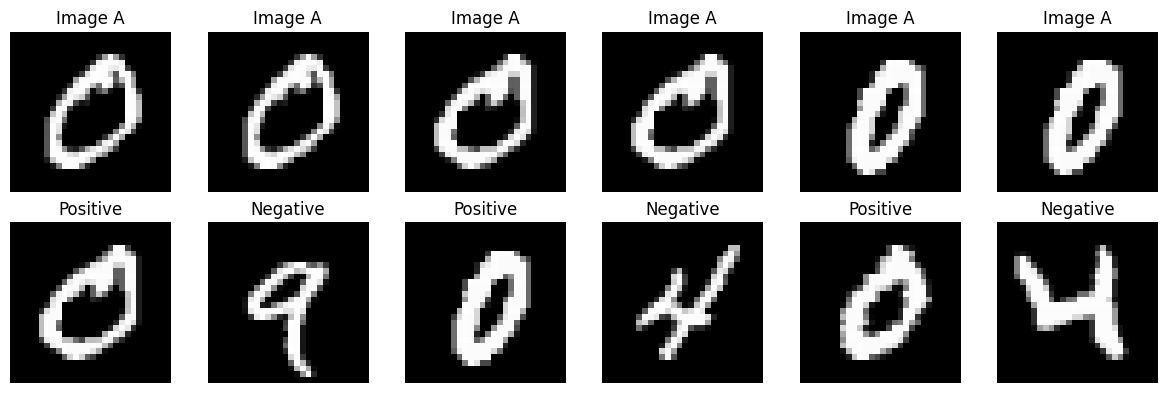

In [ ]:
# =========================================================
# VISUALIZE SAMPLE PAIRS
# =========================================================

def show_pairs(pairs, labels, num=6):
    plt.figure(figsize=(12, 4))

    for i in range(num):
        plt.subplot(2, num, i + 1)
        plt.imshow(pairs[i][0].squeeze(), cmap='gray')
        plt.axis('off')
        plt.title("Image A")

        plt.subplot(2, num, i + 1 + num)
        plt.imshow(pairs[i][1].squeeze(), cmap='gray')
        plt.axis('off')

        if labels[i] == 1:
            plt.title("Positive")
        else:
            plt.title("Negative")

    plt.tight_layout()
    plt.show()

show_pairs(train_pairs, train_labels)

In [ ]:
# =========================================================
# BUILD EMBEDDING NETWORK
# =========================================================

def build_embedding_network(input_shape):

    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,3), activation='relu')(inp)
    x = MaxPooling2D()(x)

    x = Conv2D(64, (3,3), activation='relu')(x)
    x = MaxPooling2D()(x)

    x = Flatten()(x)

    x = Dense(128, activation='relu')(x)

    output = Dense(64)(x)

    model = Model(inp, output)

    return model

input_shape = (28, 28, 1)

embedding_network = build_embedding_network(input_shape)

embedding_network.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,000 (906.25 KB)

 Trainable params: 232,000 (906.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================================================
# EUCLIDEAN DISTANCE LAYER
# =========================================================

def euclidean_distance(vectors):
    x, y = vectors
    sum_square = K.sum(K.square(x - y), axis=1, keepdims=True)
    return K.sqrt(K.maximum(sum_square, K.epsilon()))


In [ ]:
# =========================================================
# CONTRASTIVE LOSS FUNCTION
# =========================================================

def contrastive_loss(y_true, y_pred):
    margin = 1

    square_pred = K.square(y_pred)

    margin_square = K.square(K.maximum(margin - y_pred, 0))

    return K.mean(
        y_true * square_pred +
        (1 - y_true) * margin_square
    )

In [ ]:
# =========================================================
# BUILD SIAMESE NETWORK
# =========================================================

input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

embedding_a = embedding_network(input_a)
embedding_b = embedding_network(input_b)

distance = Lambda(euclidean_distance)([embedding_a, embedding_b])

siamese_model = Model([input_a, input_b], distance)

siamese_model.compile(
    loss=contrastive_loss,
    optimizer=Adam(0.001)
)

siamese_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_6        │ (None, 64)        │    232,000 │ input_layer_10[0… │
│ (Functional)        │                   │            │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ functional_6[0][… │
│                     │                   │            │ functional_6[1][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 232,000 (906.25 KB)

 Trainable params: 232,000 (906.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================================================
# TRAIN MODEL
# =========================================================

history = siamese_model.fit(
    [train_pairs[:,0], train_pairs[:,1]],
    train_labels,
    validation_data=(
        [test_pairs[:,0], test_pairs[:,1]],
        test_labels
    ),
    batch_size=64,
    epochs=10
)

Epoch 1/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0398 - val_loss: 0.0207
Epoch 2/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0173 - val_loss: 0.0166
Epoch 3/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0128 - val_loss: 0.0151
Epoch 4/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0100 - val_loss: 0.0137
Epoch 5/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0079 - val_loss: 0.0124
Epoch 6/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0063 - val_loss: 0.0120
Epoch 7/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0053 - val_loss: 0.0115
Epoch 8/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0045 - val_loss: 0.0118
Epoch 9/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0039 - val_loss: 0.0114
Epoch 10/10
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0035 - val_loss: 0.0113


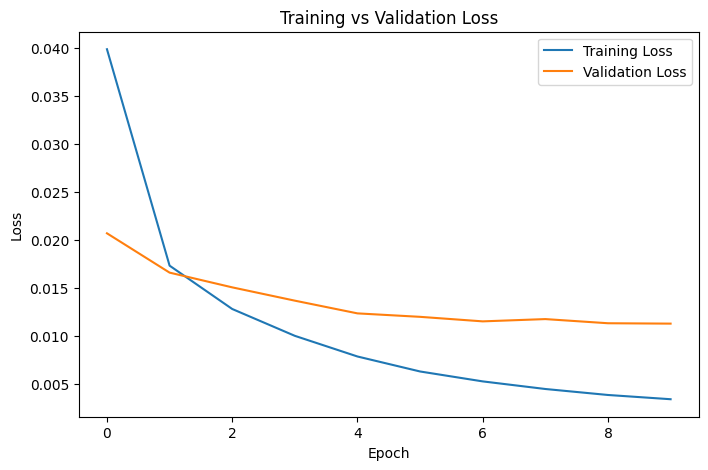

In [ ]:
# =========================================================
# PLOT TRAINING HISTORY
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
# =========================================================
# EVALUATE MODEL
# =========================================================

predictions = siamese_model.predict(
    [test_pairs[:,0], test_pairs[:,1]]
)

# Smaller distance = similar
predicted_labels = predictions.ravel() < 0.5

accuracy = accuracy_score(test_labels, predicted_labels)

print("\nTest Accuracy:", accuracy)

557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Test Accuracy: 0.9905723905723905


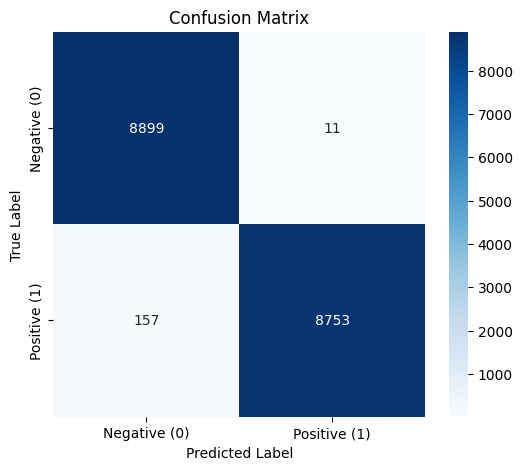


Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      1.00      0.99      8910
    Positive       1.00      0.98      0.99      8910

    accuracy                           0.99     17820
   macro avg       0.99      0.99      0.99     17820
weighted avg       0.99      0.99      0.99     17820



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print('\nClassification Report:')
print(classification_report(test_labels, predicted_labels, target_names=['Negative', 'Positive']))

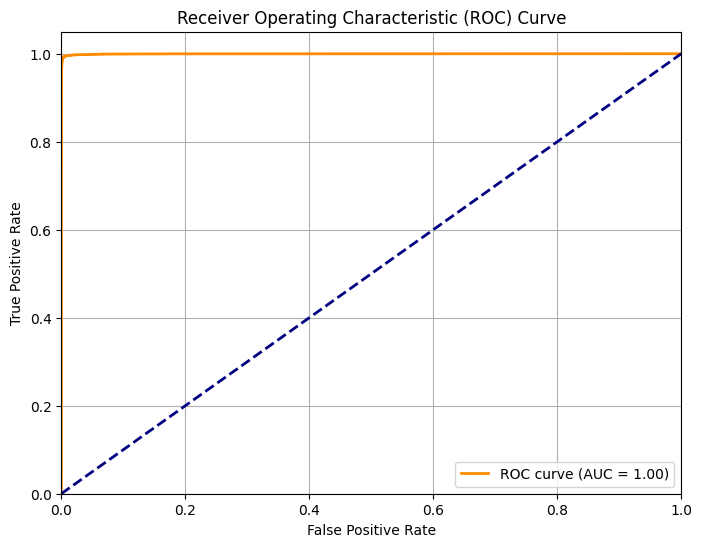

In [ ]:
similarity_scores = 1 - predictions.ravel()

fpr, tpr, thresholds = roc_curve(test_labels, similarity_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

557/557 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


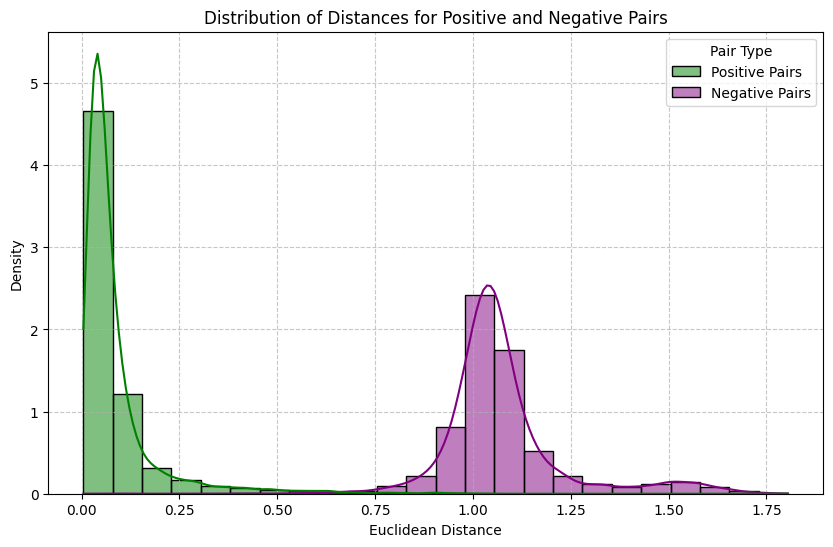

In [ ]:
import pandas as pd

# Predict distances for all test pairs
all_distances = siamese_model.predict([test_pairs[:, 0], test_pairs[:, 1]])

# Separate distances for positive and negative pairs
positive_distances = all_distances[test_labels == 1]
negative_distances = all_distances[test_labels == 0]

# Create a DataFrame for easier plotting with seaborn's hue
df_distances = pd.DataFrame({
    'Distance': np.concatenate([positive_distances.flatten(), negative_distances.flatten()]),
    'Pair Type': ['Positive Pairs'] * len(positive_distances) + ['Negative Pairs'] * len(negative_distances)
})

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_distances,
    x='Distance',
    hue='Pair Type',
    palette={'Positive Pairs': 'green', 'Negative Pairs': 'purple'},
    kde=True,
    stat='density',
    alpha=0.5
)

plt.title('Distribution of Distances for Positive and Negative Pairs')
plt.xlabel('Euclidean Distance')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# =========================================================
# ONE-SHOT RECOGNITION
# =========================================================

def one_shot_task(query_image, support_images, support_labels):

    query_batch = np.array([query_image for _ in range(len(support_images))])

    distances = siamese_model.predict(
        [query_batch, support_images],
        verbose=0
    ).ravel()

    best_match_index = np.argmin(distances)

    return (
        support_labels[best_match_index],
        distances[best_match_index],
        best_match_index
    )

# Create support set
support_indices = np.random.choice(len(x_test), 20, replace=False)

support_images = x_test[support_indices]
support_labels = y_test[support_indices]

# Query image
query_index = np.random.randint(len(x_test))

query_image = x_test[query_index]
true_label = y_test[query_index]

pred_label, distance, best_idx = one_shot_task(
    query_image,
    support_images,
    support_labels
)

print("\nOne-Shot Recognition")
print("True Label:", true_label)
print("Predicted Label:", pred_label)
print("Distance:", distance)


One-Shot Recognition
True Label: 8
Predicted Label: 8
Distance: 0.03491061


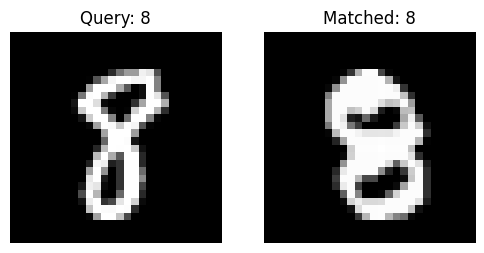

In [ ]:
# =========================================================
# VISUALIZE ONE-SHOT RESULT
# =========================================================

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(query_image.squeeze(), cmap='gray')
plt.title(f"Query: {true_label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(support_images[best_idx].squeeze(), cmap='gray')
plt.title(f"Matched: {pred_label}")
plt.axis('off')

plt.show()

In [ ]:
# =========================================================
# EXTRACT EMBEDDINGS
# =========================================================

sample_size = 2000

indices = np.random.choice(len(x_test), sample_size, replace=False)

sample_images = x_test[indices]
sample_labels = y_test[indices]

embeddings = embedding_network.predict(sample_images)

print("Embeddings Shape:", embeddings.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Embeddings Shape: (2000, 64)


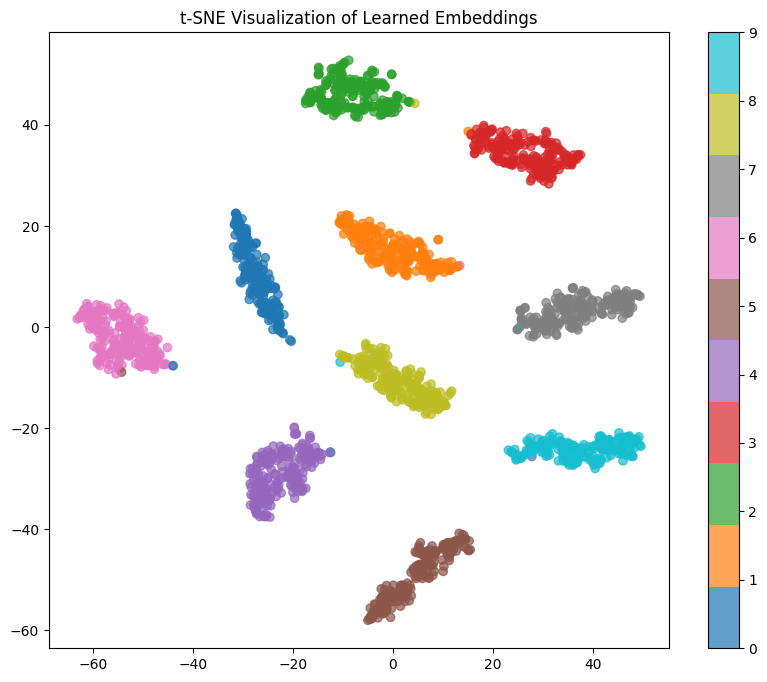

In [ ]:
# =========================================================
# t-SNE VISUALIZATION
# =========================================================

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=sample_labels,
    cmap='tab10',
    alpha=0.7
)

plt.colorbar(scatter)

plt.title("t-SNE Visualization of Learned Embeddings")

plt.show()
